In [1]:
import numpy as np
import pandas as pd

features = np.load("/content/features.npy")
df = pd.read_csv("/content/hvoid.csv")

print(features.shape)
df.head()


(2071, 1280)


,image_path,true_label,predicted_label,confidence,normalized_true,correct,void_score,uncertainty_score,density_score,outlier_score,dominant_component
0,/kaggle/input/tomato/tomato_augmented/Tomato__...,Tomato___Late_blight,Tomato_Leaf_Mold,0.3240,Tomato_Late_blight,False,2.508128,0.823917,0.284303,0.539311,uncertainty_score
1,/kaggle/input/tomato/tomato_augmented/Tomato__...,Tomato___Late_blight,Tomato_Late_blight,0.7972,Tomato_Late_blight,True,1.980181,0.232053,0.403442,0.384590,density_score
2,/kaggle/input/tomato/tomato_augmented/Tomato__...,Tomato___Late_blight,Tomato_Late_blight,0.8382,Tomato_Late_blight,True,1.824364,0.189549,0.259856,0.277208,outlier_score
3,/kaggle/input/tomato/tomato_augmented/Tomato__...,Tomato___Late_blight,Tomato_Early_blight,0.3617,Tomato_Late_blight,False,2.522149,0.786228,0.388819,0.349835,uncertainty_score
4,/kaggle/input/tomato/tomato_augmented/Tomato__...,Tomato___Late_blight,Tomato_Late_blight,0.9511,Tomato_Late_blight,True,1.850645,0.045977,0.808557,0.711460,density_score


In [2]:
from sklearn.preprocessing import normalize
X = normalize(features, norm='l2')
X.shape

(2071, 1280)

In [3]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def compute_lid_batch(X, k=20):
    """
    X: (N, d) matrix of normalized feature vectors
    k: number of neighbors
    returns lid values for each point
    """
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='auto').fit(X)
    distances, _ = nbrs.kneighbors(X)

    distances = distances[:, 1:]

    dist_k = distances[:, -1].reshape(-1, 1)
    ratios = distances / dist_k
    lids = -1.0 / np.mean(np.log(ratios + 1e-12), axis=1)

    return lids

lids = compute_lid_batch(X, k=20)
lids[:10]


array([26.62278721, 29.93145426, 29.29346455, 47.79286018, 36.13941675,
       45.05710802, 33.44283895, 29.90506177, 27.85398327, 25.0223334 ])

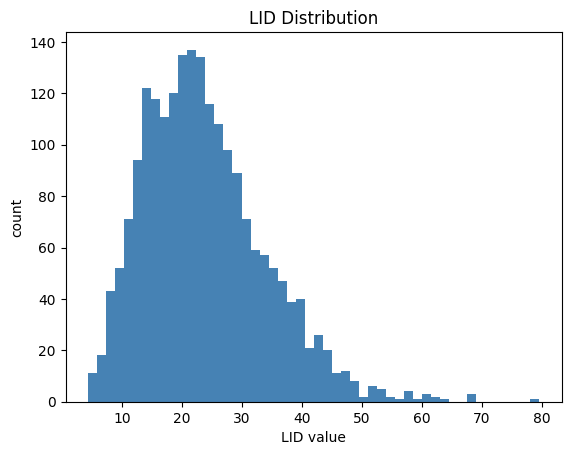

In [4]:
import matplotlib.pyplot as plt

plt.hist(lids, bins=50, color='steelblue')
plt.title("LID Distribution")
plt.xlabel("LID value")
plt.ylabel("count")
plt.show()


In [5]:
import pandas as pd

df["LID"] = lids

df[["void_score", "LID"]].corr()


,void_score,LID
void_score,1.000000,0.141505
LID,0.141505,1.000000


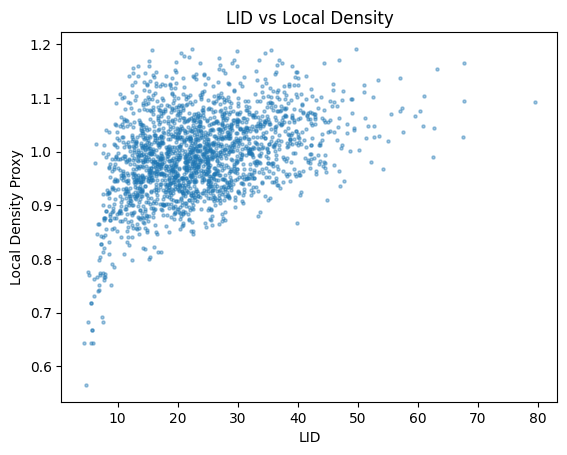

In [6]:
import numpy as np

from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=5).fit(X)
dist5, _ = nn.kneighbors(X)
density = dist5[:, -1]

plt.scatter(lids, density, s=5, alpha=0.4)
plt.xlabel("LID")
plt.ylabel("Local Density Proxy")
plt.title("LID vs Local Density")
plt.show()


In [7]:
df["void_norm"] = (df["void_score"] - df["void_score"].min()) / \
                  (df["void_score"].max() - df["void_score"].min())


In [8]:
bonus_map = {
    "uncertainty_score": 0.5,
    "density_score":     1.2,
    "outlier_score":     0.7
}

df["bonus"] = df["dominant_component"].map(bonus_map)


In [9]:
df["LID_norm"] = (df["LID"] - df["LID"].min()) / \
                 (df["LID"].max() - df["LID"].min())


In [10]:
df["w_final"] = 1.0 + 2.0*df["void_norm"] + df["bonus"] + 1.5*df["LID_norm"]


In [11]:
df.w_final.describe()

,w_final
count,2071.000000
mean,2.723417
std,0.515631
min,1.571619
25%,2.315700
50%,2.700500
75%,3.094785
max,4.677155


In [12]:
q = df["w_final"].quantile

df["aug_times"] = (
    0 * (df["w_final"] <= q(0.25)) +
    3 * ((q(0.25) < df["w_final"]) & (df["w_final"] <= q(0.50))) +
    6 * ((q(0.50) < df["w_final"]) & (df["w_final"] <= q(0.75))) +
    12 * (df["w_final"] > q(0.75))
).astype(int)



In [13]:
df["aug_times"].describe()

,aug_times
count,2071.000000
mean,5.249638
std,4.439172
min,0.000000
25%,1.500000
50%,3.000000
75%,9.000000
max,12.000000


In [14]:
df.to_csv("df_augmented_metadata.csv", index=False)